# Employee Attrition Prediction using Artificial Neural Networks (ANN)

## Problem Statement

Employee attrition is a critical challenge for organizations as high turnover leads to increased recruitment costs, productivity loss, and reduced employee morale.

The objective of this project is to build an Artificial Neural Network (ANN) model capable of predicting whether an employee is likely to leave the organization based on demographic, job-related, and performance-related attributes.

## Objectives

- Perform Exploratory Data Analysis (EDA)
- Preprocess and encode categorical features
- Build an ANN using TensorFlow/Keras
- Evaluate model performance
- Save trained artifacts for deployment
- Create an inference pipeline for future predictions

## Importing libraries

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import joblib

## Load the dataset

In [4]:
df = pd.read_csv("HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [5]:
df.shape

(1470, 35)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
df.isnull().sum().sum()

np.int64(0)

## Data cleaning

In [9]:
df['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [10]:
df['Attrition'].value_counts(normalize=True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

In [12]:
# check constant columns

for col in df.columns:
    print(col, ":", df[col].nunique())

Age : 43
Attrition : 2
BusinessTravel : 3
DailyRate : 886
Department : 3
DistanceFromHome : 29
Education : 5
EducationField : 6
EmployeeCount : 1
EmployeeNumber : 1470
EnvironmentSatisfaction : 4
Gender : 2
HourlyRate : 71
JobInvolvement : 4
JobLevel : 5
JobRole : 9
JobSatisfaction : 4
MaritalStatus : 3
MonthlyIncome : 1349
MonthlyRate : 1427
NumCompaniesWorked : 10
Over18 : 1
OverTime : 2
PercentSalaryHike : 15
PerformanceRating : 2
RelationshipSatisfaction : 4
StandardHours : 1
StockOptionLevel : 4
TotalWorkingYears : 40
TrainingTimesLastYear : 7
WorkLifeBalance : 4
YearsAtCompany : 37
YearsInCurrentRole : 19
YearsSinceLastPromotion : 16
YearsWithCurrManager : 18


In [13]:
# check categorical columns

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    print("\n",col)
    print(df[col].unique())


 Attrition
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

 BusinessTravel
<ArrowStringArray>
['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
Length: 3, dtype: str

 Department
<ArrowStringArray>
['Sales', 'Research & Development', 'Human Resources']
Length: 3, dtype: str

 EducationField
<ArrowStringArray>
[   'Life Sciences',            'Other',          'Medical',
        'Marketing', 'Technical Degree',  'Human Resources']
Length: 6, dtype: str

 Gender
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

 JobRole
<ArrowStringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str

 MaritalStatus
<ArrowStringArray>
['Single', 'Married', 'Divorced']
Length: 3, dtype: str

 Over18
<ArrowStringArray>
['Y']
Length: 1, dtype: str


In [14]:
df = df.drop(
    columns=[
        'EmployeeCount',
        'Over18',
        'StandardHours',
        'EmployeeNumber'
    ]
)

df.shape

(1470, 31)

## EDA

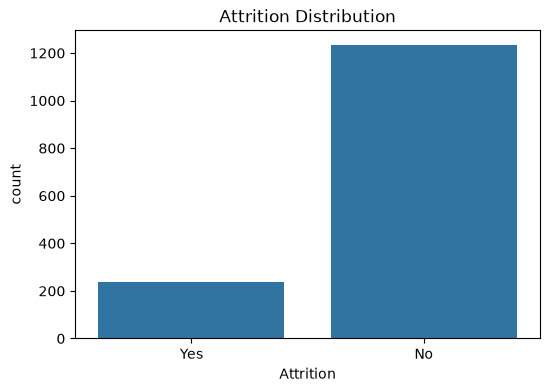

In [15]:
# Target distribution

plt.figure(figsize=(6,4))
sns.countplot(
    x='Attrition',
    data=df
)
plt.title('Attrition Distribution')
plt.show()

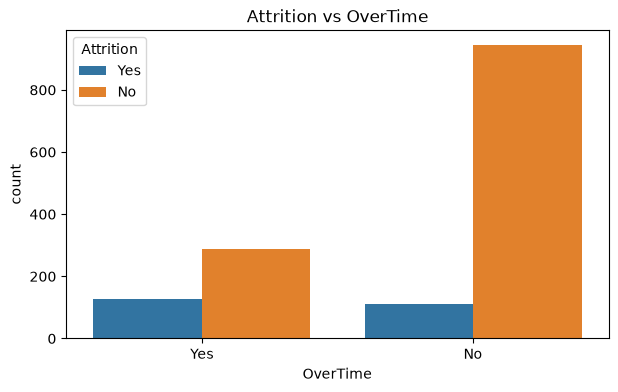

In [16]:
# Attrition vs Overtime

plt.figure(figsize=(7,4))
sns.countplot(
    x='OverTime',
    hue='Attrition',
    data=df
)
plt.title('Attrition vs OverTime')
plt.show()

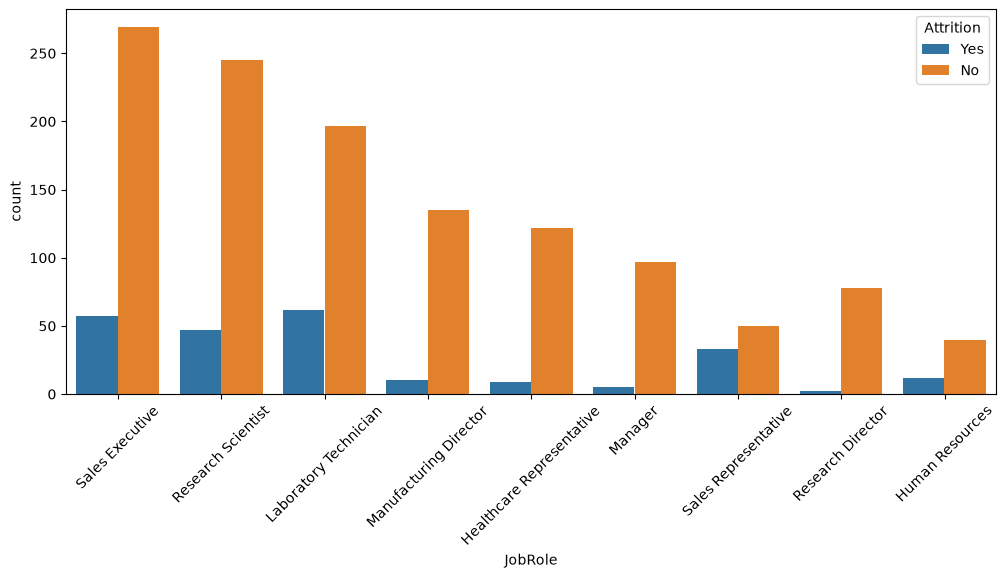

In [18]:
# Attrition vs JobRole

plt.figure(figsize=(12,5))
sns.countplot(
    x='JobRole',
    hue='Attrition',
    data=df
)
plt.xticks(rotation=45)
plt.show()

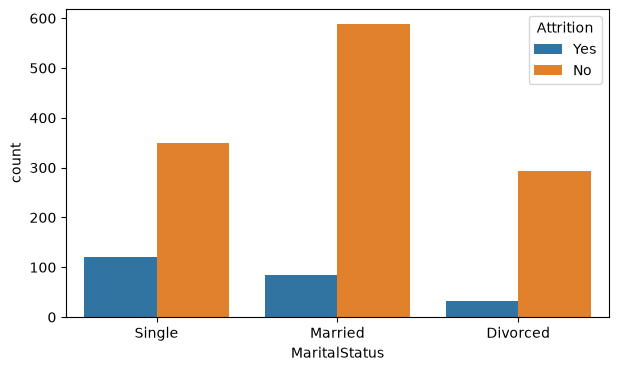

In [19]:
# Attrition vs Marital Status

plt.figure(figsize=(7,4))
sns.countplot(
    x='MaritalStatus',
    hue='Attrition',
    data=df
)
plt.show()

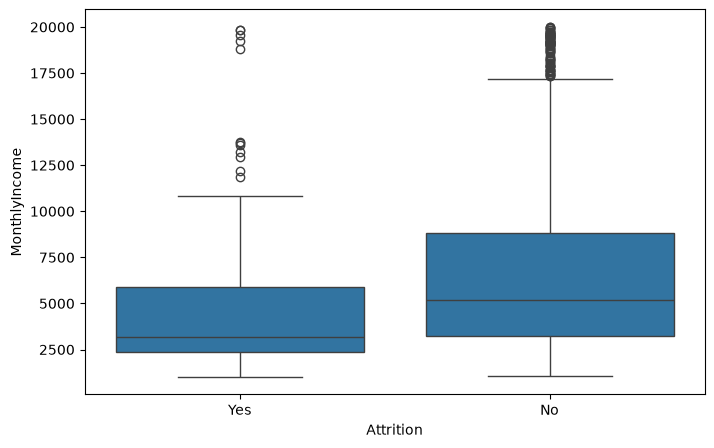

In [21]:
# Monthly Income vs Attrition

plt.figure(figsize=(8,5))
sns.boxplot(
    x='Attrition',
    y='MonthlyIncome',
    data=df
)
plt.show()

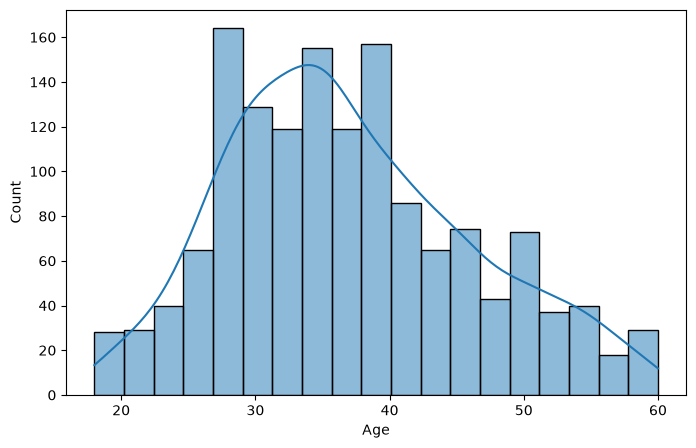

In [23]:
# Age distribution
plt.figure(figsize=(8,5))
sns.histplot(
    df['Age'],
    kde=True
)
plt.show()

## Feature Engineering and Encoding

In [24]:
X = df.drop('Attrition', axis=1)
y = df['Attrition']

In [25]:
# Encode targets

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

In [27]:
# One hot encode features

X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

In [28]:
X.shape

(1470, 44)

In [29]:
X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,0,0,0,0,0,1,0,0,1,1
1,49,279,8,1,3,61,2,2,2,5130,...,0,0,0,0,1,0,0,1,0,0
2,37,1373,2,2,4,92,2,1,3,2090,...,1,0,0,0,0,0,0,0,1,1
3,33,1392,3,4,4,56,3,1,3,2909,...,0,0,0,0,1,0,0,1,0,1
4,27,591,2,1,1,40,3,1,2,3468,...,1,0,0,0,0,0,0,1,0,0


## Train Test Split

In [30]:
# Using stratification because target is unbalanced

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
print(X_train.shape)
print(X_test.shape)

(1176, 44)
(294, 44)


## Feature Scaling

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
# checking for scaled values

X_train[:2]

array([[ 1.09019402,  1.04945488, -0.89991452,  1.06420933, -0.65870975,
        -0.90843647,  1.79528209,  1.76218896, -0.64799683,  2.02675233,
         0.93128918,  1.33076293, -0.33712854, -0.43206495,  0.24021828,
         2.61310031,  2.26148214, -0.60538935,  0.33762109, -0.66570587,
        -0.62536487, -0.36802436, -0.6164065 , -0.48640833,  0.64829766,
        -1.36175216,  1.49357599,  1.2062814 , -0.35860682, -0.66953406,
        -0.23591375, -0.3292238 , -1.22128024, -0.19006143, -0.47299607,
         3.62886686, -0.32604128, -0.23791548, -0.479714  , -0.54984141,
        -0.23186945, -0.92144268, -0.68154831, -0.63772923],
       [-1.6348276 , -0.52344929, -0.89991452, -1.85533229,  0.26020207,
         1.69411125,  0.37356375, -0.98626491,  1.15352627, -0.8644084 ,
         0.68274179, -1.08370434, -0.33712854, -0.43206495,  0.24021828,
         0.24742982, -1.07267466, -0.60538935,  0.33762109, -0.83007079,
        -0.9056351 , -0.05688371, -0.89704685, -0.48640833,  0.

# Buidling ANN (version #1)

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

model = Sequential()

model.add(Dense(
    64,
    activation='relu',
    input_shape=(X_train.shape[1],)
))

model.add(Dropout(0.3))

model.add(Dense(
    32,
    activation='relu'
))

model.add(Dropout(0.3))

model.add(Dense(
    16,
    activation='relu'
))

model.add(Dense(
    1,
    activation='sigmoid'
))

## Model summary

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,505 (21.50 KB)

 Trainable params: 5,505 (21.50 KB)

 Non-trainable params: 0 (0.00 B)